In [1]:
import numpy as np
import matplotlib.pyplot as plt

Covariance Matrix:
[[5.34383294 5.36576099]
 [5.36576099 5.80661362]]

Eigenvalues:  [10.94597113  0.20447543]
Eigenvectors:
[[-0.69170678 -0.72217846]
 [-0.72217846  0.69170678]]

PC1 explains 98.2% variance
PC2 explains 1.8% variance


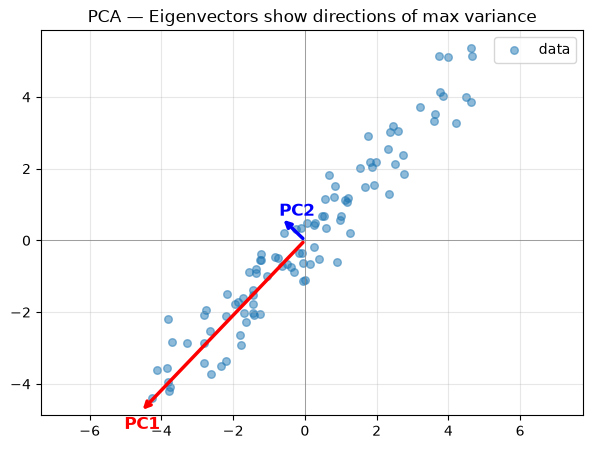

In [2]:
# Cell 2 — Version 1: covariance matrix + eigenvectors
np.random.seed(42)
# correlated 2D data
X = np.dot(np.random.randn(100, 2),
           np.array([[2, 1.5], [1.5, 2]]))

# step 1: mean centre
X_centred = X - X.mean(axis=0)

# step 2: covariance matrix
cov = np.cov(X_centred.T)
print("Covariance Matrix:")
print(cov)

# step 3: eigenvectors + eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(cov)
sorted_idx   = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print(f"\nEigenvalues:  {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")
print(f"\nPC1 explains {eigenvalues[0]/eigenvalues.sum()*100:.1f}% variance")
print(f"PC2 explains {eigenvalues[1]/eigenvalues.sum()*100:.1f}% variance")

# plot
plt.figure(figsize=(7, 5))
plt.scatter(X_centred[:,0], X_centred[:,1], alpha=0.5, s=30, label='data')
origin = [0, 0]
scale  = 2
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    plt.annotate('', xy=vec*scale*np.sqrt(val),
                 xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=['red','blue'][i],
                                 lw=2.5))
    plt.text(*(vec*scale*np.sqrt(val)*1.1), f'PC{i+1}',
             color=['red','blue'][i], fontsize=12, fontweight='bold')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('PCA — Eigenvectors show directions of max variance')
plt.legend(); plt.grid(True, alpha=0.3); plt.axis('equal'); plt.show()

Original shape:  (100, 2)
Reduced to 1D:   (100,)
Reduced to 2D:   (100, 2)


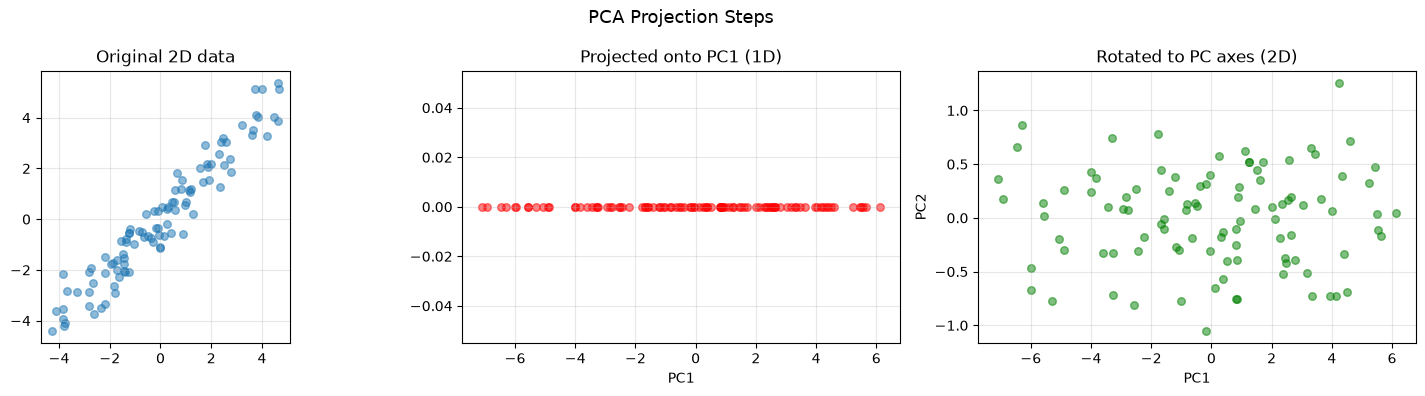

In [3]:
# Cell 3 — Version 2: project data onto PC1 (dimensionality reduction)
# Project: X_reduced = X_centred @ eigenvectors

X_1d = X_centred @ eigenvectors[:, 0]   # project onto PC1 only
X_2d = X_centred @ eigenvectors          # project onto both PCs

print(f"Original shape:  {X.shape}")
print(f"Reduced to 1D:   {X_1d.shape}")
print(f"Reduced to 2D:   {X_2d.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_centred[:,0], X_centred[:,1], alpha=0.5, s=30)
axes[0].set_title('Original 2D data'); axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].scatter(X_1d, np.zeros_like(X_1d), alpha=0.5, s=30, color='red')
axes[1].set_title('Projected onto PC1 (1D)')
axes[1].set_xlabel('PC1'); axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_2d[:,0], X_2d[:,1], alpha=0.5, s=30, color='green')
axes[2].set_title('Rotated to PC axes (2D)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)

plt.suptitle('PCA Projection Steps', fontsize=13)
plt.tight_layout(); plt.show()

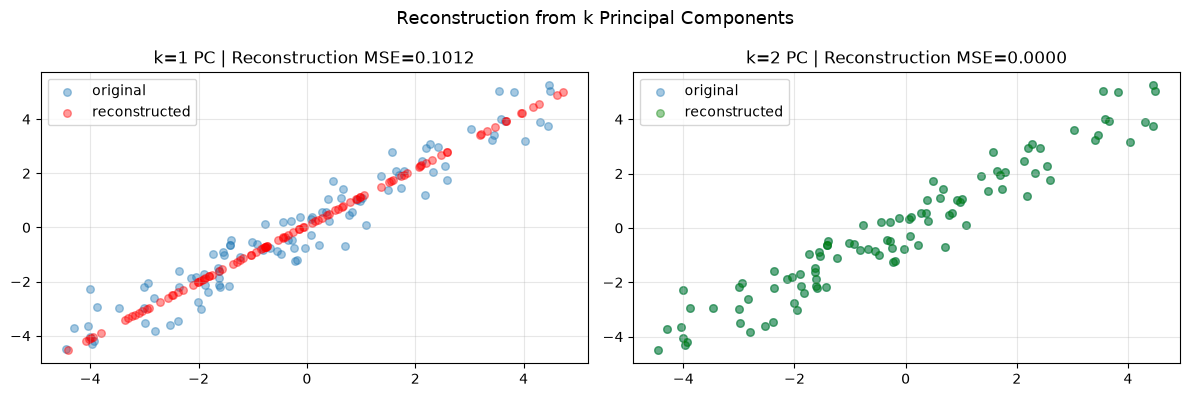

In [4]:
# Cell 4 — Version 3: reconstruction error
# Reconstruct from k PCs and measure what information is lost

X_centred = X - X.mean(axis=0)
cov = np.cov(X_centred.T)
eigenvalues, eigenvectors = np.linalg.eig(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['red', 'green']

for ax, k, col in zip(axes, [1, 2], colors):
    W           = eigenvectors[:, :k]        # top k eigenvectors
    X_reduced   = X_centred @ W              # project
    X_reconstructed = X_reduced @ W.T + X.mean(axis=0)   # reconstruct
    error = np.mean((X - X_reconstructed)**2)

    ax.scatter(X[:,0], X[:,1], alpha=0.4, s=30, label='original')
    ax.scatter(X_reconstructed[:,0], X_reconstructed[:,1],
               alpha=0.4, s=30, color=col, label='reconstructed')
    ax.set_title(f'k={k} PC | Reconstruction MSE={error:.4f}')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Reconstruction from k Principal Components', fontsize=13)
plt.tight_layout(); plt.show()

PC1: 91.6%  PC2: 5.3%  PC3: 3.1%
2 PCs capture 96.9% of variance


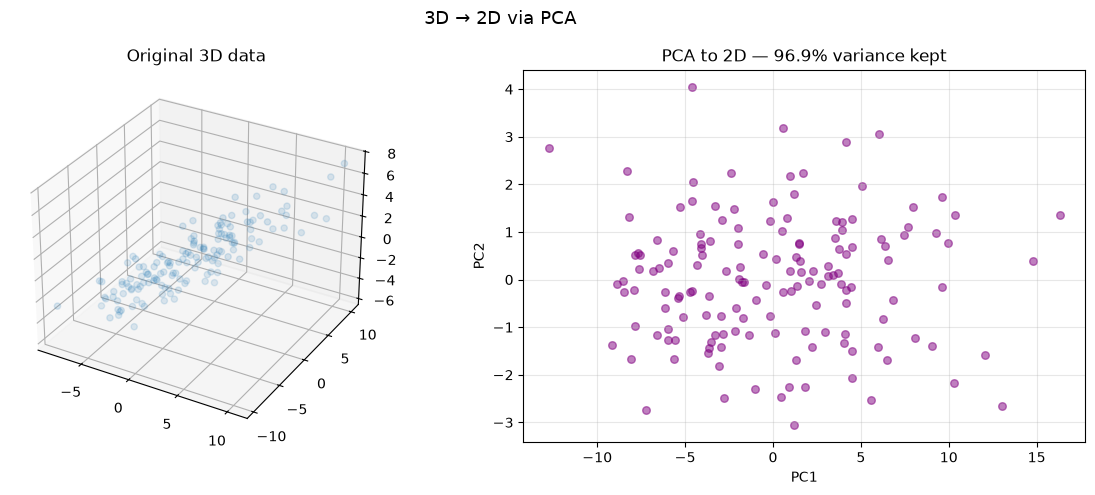

In [5]:
# Cell 5 — Version 4: PCA on 3D data → visualise in 2D
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)
# 3D data with structure
X3d = np.dot(np.random.randn(150, 3),
             np.array([[3,2,1],[2,3,1],[1,1,2]]))

X3d_c = X3d - X3d.mean(axis=0)
cov3  = np.cov(X3d_c.T)
vals, vecs = np.linalg.eig(cov3)
idx  = np.argsort(vals)[::-1]
vecs = vecs[:, idx]; vals = vals[idx]

X_pca2d = X3d_c @ vecs[:, :2]

ev_ratio = vals / vals.sum()
print(f"PC1: {ev_ratio[0]*100:.1f}%  PC2: {ev_ratio[1]*100:.1f}%  "
      f"PC3: {ev_ratio[2]*100:.1f}%")
print(f"2 PCs capture {(ev_ratio[0]+ev_ratio[1])*100:.1f}% of variance")

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X3d[:,0], X3d[:,1], X3d[:,2], alpha=0.4, s=20)
ax1.set_title('Original 3D data')

ax2 = fig.add_subplot(122)
ax2.scatter(X_pca2d[:,0], X_pca2d[:,1], alpha=0.5, s=30, color='purple')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title(f'PCA to 2D — {(ev_ratio[0]+ev_ratio[1])*100:.1f}% variance kept')
ax2.grid(True, alpha=0.3)

plt.suptitle('3D → 2D via PCA', fontsize=13)
plt.tight_layout(); plt.show()